In [1]:
%cd ..

import torch
import numpy as np
import matplotlib.pyplot as plt
from cs_vit.net import Poser

/data_1/renkaiwen/CS-ViT/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/data_1/renkaiwen/CS-ViT


In [2]:
device = torch.device("cuda:0")

In [3]:
model = Poser(
    backbone="model/microsoft/swinv2-base-patch4-window16-256",
    num_pose_query=16,
    num_spatial_layer=6,
    spatial_layer_type="encoder",
    num_temporal_layer=2,
    expansion_ratio=1.25,
    temporal_supervision="realtime",
    trope_scalar=20.0,
    num_latent_layer=None,
    persp_decorate="patch"
)
# model.load_state_dict(torch.load("checkpoints/temporal_ih26m-dexycb-ho3d-swinb_spenc_addpat_ti_20250607_1/checkpoint_1.pt")["merged"], strict=False)
# model.load_state_dict(torch.load("checkpoints/temporal_ih26m-dexycb-ho3d-swinb_spenc_addpat_ti_20250607_1/checkpoint.pt")["merged"], strict=False)
model.load_state_dict(torch.load("checkpoints/spatial_dexycb_swinb_spenc_addpat_ti_20250703_1/checkpoint_30.pt")["merged"], strict=False)
model.phase(Poser.TrainingPhase.SPATIAL)
model.to(device)
pass

In [4]:
from cs_vit.dataset import DexYCB, InterHand26MSeq, HO3D
from cs_vit.config import FinetuneConfig as cfg
from cs_vit.utils.misc import move_to_device
from torch.utils.data.dataloader import DataLoader

In [5]:
# dataset = HO3D(
#     root=cfg.ho3d_root,
#     num_frames=7,
#     data_split="evaluation",
#     img_size=cfg.img_size,
#     expansion_ratio=cfg.expansion_ratio
# )
dataset = DexYCB(
    root=cfg.dexycb_root,
    num_frames=1,
    protocol="s1",
    data_split="test",
    img_size=cfg.img_size,
    expansion_ratio=1.25
)
# dataset = InterHand26MSeq(
#     root=cfg.ih26mseq_root,
#     num_frames=1,
#     data_split="test",
#     img_size=cfg.img_size,
#     expansion_ratio=cfg.expansion_ratio
# )
dataloader = DataLoader(dataset, shuffle=True, batch_size=4, collate_fn=InterHand26MSeq.collate_fn)
dataiter = iter(dataloader)

In [21]:
batch = next(dataiter)
batch = move_to_device(batch, device)

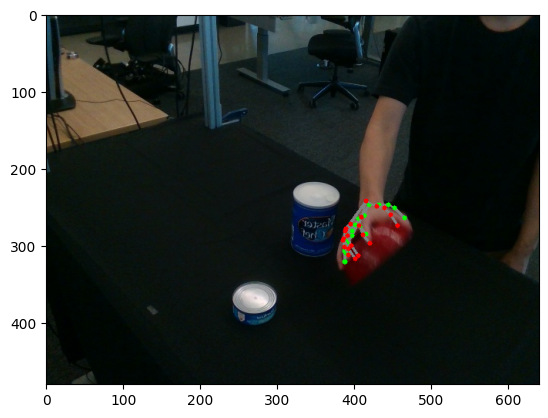

In [22]:
model.phase(Poser.TrainingPhase.INFERENCE)
with torch.inference_mode():
    predict = model(batch)
plt.imshow(predict["logs"]["image"]["img_reproj"][0].permute(1,2,0))

In [23]:
model.phase(Poser.TrainingPhase.INFERENCE)
with torch.inference_mode():
    predict = model.predict_batch(
        img_tensor=batch["patches"],
        square_bboxes=batch["square_bboxes"],
        timestamp=batch["timestamp"],
        focal=batch["focal"],
        princpt=batch["princpt"],
    )

In [24]:
import smplx

rmano_layer = smplx.create("model/smplx_models", "mano", is_rhand=True, use_pca=False).to(device)

pose_gt = batch["mano_pose"]
shape_gt = batch["mano_shape"]
joint_gt = batch["joint_cam"]

pose_gt.shape, shape_gt.shape

output = rmano_layer(
    betas=shape_gt[0, -1, None],
    global_orient=pose_gt[0, -1, None, :3],
    hand_pose=pose_gt[0, -1, None, 3:],
    transl=torch.zeros(size=(1, 3)).to(device)
)

verts_mano = output.vertices[0] * 1e3
joint_mano = output.joints[0] * 1e3
verts_mano = (verts_mano - joint_mano[:1]) + joint_gt[0, 0, :1]

focal = batch["focal"][0, -1].to(device)
princpt = batch["princpt"][0, -1].to(device)
verts_mano_u = verts_mano[:, 0] * focal[0] / verts_mano[:, 2] + princpt[0]
verts_mano_v = verts_mano[:, 1] * focal[1] / verts_mano[:, 2] + princpt[1]
verts_mano_reproj = torch.stack([verts_mano_u, verts_mano_v], dim=-1)

(verts_mano - predict["verts_cam"][0, 0]).norm(dim=-1, p=2).mean()

tensor(64.4838, device='cuda:0')

In [25]:
import cv2
import open3d as o3d
import numpy as np

def render_mesh(meshes, focal, princpt, width=512, height=512):
    # 设置相机参数
    intrinsic = o3d.camera.PinholeCameraIntrinsic(
        width=width, height=height,
        fx=focal[0], fy=focal[1],
        cx=princpt[0], cy=princpt[1]
    )
    extrinsic = np.eye(4)

    try:
        # 创建渲染器
        render = o3d.visualization.rendering.OffscreenRenderer(width, height)

        # 设置材质和场景
        mat = o3d.visualization.rendering.MaterialRecord()
        mat.shader = "defaultLit"
        for i, mesh in enumerate(meshes):
            render.scene.add_geometry(f"mano_{i}", mesh, mat)
        render.setup_camera(intrinsic, extrinsic)
        render.scene.set_background([0, 0, 0, 0])

        # 设置光照
        render.scene.set_lighting(
            o3d.visualization.rendering.Open3DScene.LightingProfile.NO_SHADOWS,
            (0, 0, 0)
        )
        render.scene.scene.set_sun_light(
            direction=[1.0, 1.0, 1.0],
            color=[1.0, 1.0, 1.0],
            intensity=50000
        )

        # 渲染图像
        image = render.render_to_image()

        # 显式清理
        for i, _ in enumerate(meshes):
            render.scene.remove_geometry(f"mano_{i}")
        del render

        return image

    except Exception as e:
        print(f"渲染错误: {e}")
        return None

mesh_gt = o3d.geometry.TriangleMesh()
mesh_gt.vertices = o3d.utility.Vector3dVector(verts_mano.detach().cpu().numpy())
mesh_gt.triangles = o3d.utility.Vector3iVector(rmano_layer.faces)
mesh_gt.paint_uniform_color((0.0, 1.0, 0.0))
mesh_gt.compute_vertex_normals()

mesh_pred = o3d.geometry.TriangleMesh()
mesh_pred.vertices = o3d.utility.Vector3dVector(predict["verts_cam"][0, -1].detach().cpu().numpy())
mesh_pred.triangles = o3d.utility.Vector3iVector(rmano_layer.faces)
mesh_pred.paint_uniform_color((1.0, 0.0, 0.0))
mesh_pred.compute_vertex_normals()

intrinsic = o3d.camera.PinholeCameraIntrinsic(
    width=512,
    height=512,
    fx=focal[0].item(),
    fy=focal[1].item(),
    cx=princpt[0].item(),
    cy=princpt[1].item()
)
extrinsic = np.eye(4)

img = cv2.imread(batch["imgs_path"][0][-1])
height, width, _ = img.shape

image_1 = render_mesh([mesh_pred], focal.tolist(), princpt.tolist(), width=width, height=height)
image_2 = render_mesh([mesh_gt, mesh_pred], focal.tolist(), princpt.tolist(), width=width, height=height)

o3d.io.write_image("render/image_1.png", image_1)
o3d.io.write_image("render/image_2.png", image_2)

[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x564ac3dee510 (threading is enabled)
EGL(1.5)
OpenGL(4.1)
[Open3D INFO] EGL headless mode enabled.
FEngine (64 bits) created at 0x564ac3dee510 (threading is enabled)
EGL(1.5)
OpenGL(4.1)


True